In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"
df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")
centrals = resolved[
    resolved["IsSatellite"] == False
].copy()

satellites = resolved[
    (resolved["IsSatellite"] == True) &
    resolved[["x", "y", "z"]].notna().all(axis=1)
].copy()

nearest_distances = []

for _, central in centrals.iterrows():

    sats = satellites[
        satellites["GroupID"] == central["GroupID"]
    ]

    if len(sats) == 0:
        nearest_distances.append(np.nan)
        continue

    box_size = 205000.0  # TNG300-1 box size in ckpc/h

    dx = np.abs(sats["x"].to_numpy() - central["x"])
    dy = np.abs(sats["y"].to_numpy() - central["y"])
    dz = np.abs(sats["z"].to_numpy() - central["z"])

    dx = np.minimum(dx, box_size - dx)
    dy = np.minimum(dy, box_size - dy)
    dz = np.minimum(dz, box_size - dz)

    distances = np.sqrt(dx**2 + dy**2 + dz**2)


    nearest_distances.append(np.min(distances))

centrals["NearestSatelliteDistance"] = nearest_distances
dmdgs = centrals[
    centrals["f_DM"] < 0.5
].copy()
dmdgs_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"Centrals: {len(centrals):,}")
print(f"DMDGS (total): {len(dmdgs):,}")
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme):,}")
print(f"DMDGS Fraction: {(len(dmdgs_non_extreme) / len(centrals)):,}")

Total catalog objects: 13,922,457
Resolved galaxies: 154,638
Centrals: 93,039
DMDGS (total): 96
DMDGS (non-tidal stripping): 96
DMDGS Fraction: 0.0010318253635572179


In [16]:
h = 0.6774
centrals["M_star_Msun"] = centrals["M_star"] * 1e10 / h
centrals["R_half_star_log"] = np.log(centrals["R_half_star"])
centrals["M_star_Msun_log"] = np.log(centrals["M_star_Msun"])
non_dmdg_group_selected = centrals[centrals["f_DM"] >= 0.5]

In [17]:
print(non_dmdg_group_selected.keys())
m, b = np.polyfit(non_dmdg_group_selected["M_star_Msun_log"], non_dmdg_group_selected["R_half_star_log"], 1)
print(f"Equation: y = {m:.4f}x + {b:.4f}")

Index(['SubhaloID', 'GroupID', 'M_DM_2Rh', 'M_total_2Rh', 'f_DM', 'M_star',
       'M_gas', 'N_gas', 'N_DM', 'N_star', 'N_BH', 'R_half_star', 'x', 'y',
       'z', 'SFR', 'Vmax', 'VmaxRad', 'SubhaloFlag', 'Host_M200c',
       'Host_R200c', 'IsCentral', 'IsSatellite', 'DistanceToHost',
       'r_over_R200c', 'DMDG_fDM_lt_0.5', 'NearestSatelliteDistance',
       'R_half_star_log', 'M_star_Msun', 'M_star_Msun_log'],
      dtype='str')
Equation: y = 0.2709x + -5.0890


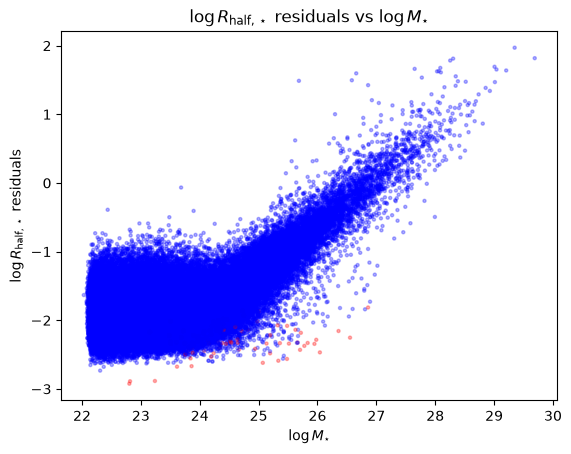

In [28]:
centrals["R_half_star_log_residual"] = centrals["R_half_star_log"] - (m * centrals["M_star_Msun_log"] + b)
colors = []
x_values = []
y_values = []
for i, row in centrals.iterrows():
   x_values.append(row["M_star_Msun_log"])
   y_values.append(row["R_half_star_log_residual"])
   if row["f_DM"] < 0.5:
      colors.append("red") 
   else:
      colors.append("blue")
plt.scatter(x_values, y_values, c=colors, s=5, alpha=0.3)
plt.title("$\\log R_{\\text{half}, \\star} \\text{ residuals vs }  \\log M_{\\star}$")
plt.ylabel("$\\log R_{\\text{half}, \\star} \\text{ residuals}$")
plt.xlabel("$\\log M_{\\star}$")
plt.show()

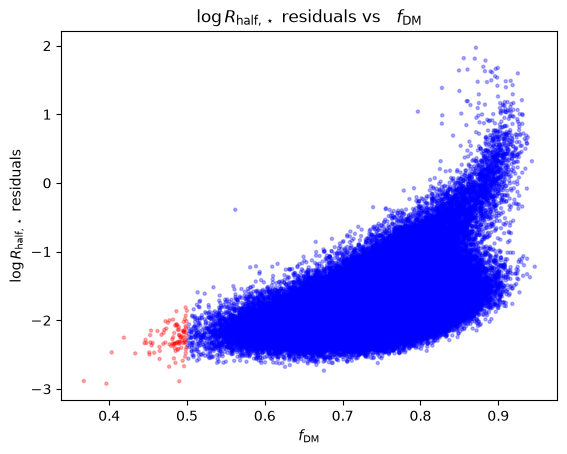

In [32]:
centrals["R_half_star_log_residual"] = centrals["R_half_star_log"] - (m * centrals["M_star_Msun_log"] + b)
colors = []
x_values = []
y_values = []
for i, row in centrals.iterrows():
   x_values.append(row["f_DM"])
   y_values.append(row["R_half_star_log_residual"])
   if row["f_DM"] < 0.5:
      colors.append("red") 
   else:
      colors.append("blue")
plt.scatter(x_values, y_values, c=colors, s=5, alpha=0.3)

plt.title("$\\log R_{\\text{half}, \\star}$ residuals vs   $f_\\text{DM}$")
plt.xlabel("$f_\\text{DM}$")
plt.ylabel("$\\log R_{\\text{half}, \\star} \\text{ residuals}$")
plt.show()

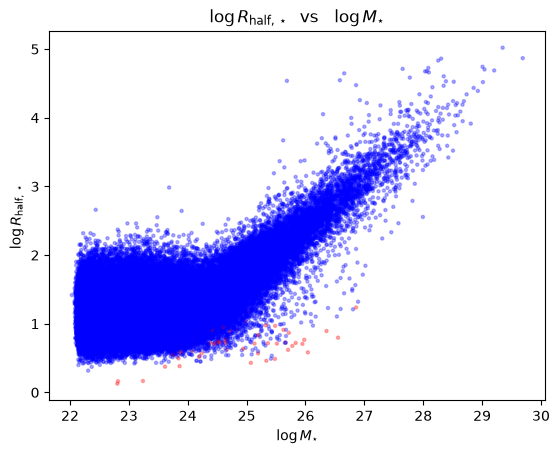

In [31]:
centrals["R_half_star_log_residual"] = centrals["R_half_star_log"] - (m * centrals["M_star_Msun_log"] + b)
colors = []
x_values = []
y_values = []
for i, row in centrals.iterrows():
   x_values.append(row["M_star_Msun_log"])
   y_values.append(row["R_half_star_log"])
   if row["f_DM"] < 0.5:
      colors.append("red") 
   else:
      colors.append("blue")
plt.title("$\\log R_{\\text{half}, \\star}$  vs   $\\log M_{\\star}$")
plt.xlabel("$\\log M_{\\star}$")
plt.ylabel("$\\log R_{\\text{half}, \\star}$")
plt.scatter(x_values, y_values, c=colors, s=5, alpha=0.3)
plt.show()